# Patterns that determine the success of the game

* The purpose of this study is to understand what patterns determine the success of the game. We will need this to make a forecast for 2017 for our advertising company. A dataset with all the necessary information was provided for analysis.
* Action plan:
    * Get dataset
    * Process data and columns
    * Build graphs and get information

<b>Step 1. Open the data file and study the general information<b>

Importing libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as st

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


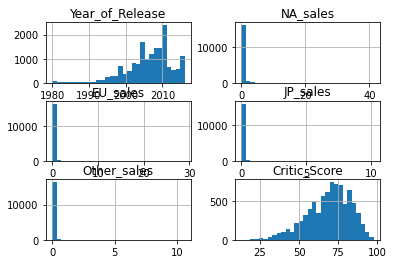

In [2]:
data = pd.read_csv('/datasets/games.csv')
original_data = data
data.info()
display(data.head(50))
data.hist(bins=30);

<b>Step 2. Prepare the data<b>

Let's immediately convert all column names to lower case.

In [3]:
data = data.rename(columns={c: c.lower() for c in data.columns})
print(data.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


The game's release year must be converted to an integer type, since the year cannot be non-integer.

The user rating should be changed to the float type, since this column contains numbers - rating.

The remaining columns do not need to change their type.

In [4]:
data['year_of_release'] = data['year_of_release'].astype('Int64')
data.loc[data.user_score == 'tbd', 'user_score'] = np.nan
data.user_score = data.user_score.astype('float')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


It is not possible to fill in missing values ​​in the name column, since there is no way to identify missing game names.

It will not be possible to fill in the year based on other data.

It is impossible to fill in the game genre based on other data.

User ratings based on other data cannot be filled in.

It is not possible to fill out critics' ratings based on other data.


You can try to fill out the rating by game genre, usually if the game genre is, for example, slasher, then for other games in the slasher genre it will almost always be the same.

In [5]:
my_pivot = pd.pivot_table(data, index='rating', columns='genre', values='platform', aggfunc='count')
display(my_pivot)

def filling_rating(row):
    if row['rating'] == np.nan or pd.isnull(row['rating']) and not pd.isnull(row['genre']):
        return my_pivot[row['genre']].idxmax()
    return row['rating']


data['rating'] = data.apply(filling_rating, axis=1)
data.info()

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
rating,,,,,,,,,,,,
AO,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,416.0,162.0,8.0,457.0,358.0,289.0,585.0,84.0,48.0,325.0,1188.0,70.0
E10+,481.0,68.0,19.0,167.0,144.0,43.0,96.0,111.0,58.0,48.0,107.0,78.0
EC,1.0,2.0,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K-A,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
M,608.0,99.0,49.0,13.0,3.0,NaN,18.0,162.0,565.0,5.0,16.0,25.0
RP,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0
T,681.0,115.0,362.0,239.0,64.0,10.0,172.0,420.0,348.0,190.0,198.0,162.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


In [6]:
display(original_data.query('User_Score.isna() and Critic_Score.isna() and Rating.isna()').shape)
display(original_data.query('User_Score.isna() and Critic_Score.isna() and Rating.isna()'))
display(original_data.query('User_Score.isna() and Critic_Score.isna() and Rating.isna() and Year_of_Release > 2010'))


(6621, 11)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN
33,Pokemon X/Pokemon Y,3DS,2013.0,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014.0,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,NaN
72,Minecraft,X360,2013.0,Misc,5.70,2.65,0.02,0.81,NaN,NaN,NaN
83,Pokemon Black 2/Pokemon White 2,DS,2012.0,Role-Playing,2.79,1.72,3.14,0.41,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16707,Aiyoku no Eustia,PSV,2014.0,Misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN


Most likely, gaps in the data may have occurred due to human error or mechanical error. You may notice that if information is missing from the user rating column, it is also missing from the critic rating column and the game rating column. If we are talking about popular games, for example Super Mario Bros., where sales are huge, then most likely the game was simply not rated, since at that time there was simply no service for rating games with their detailed information such as age ratings. And if we are talking about games, for example LMA Manager 2007, where sales are slightly higher than 0, we can assume that none of the users simply left a review for the game. You can also notice that the newer the game, the fewer gaps it has in these 3 columns, which means we can assume that older games were not on services where users and critics could rate the game. If we are talking about the genre column, where there are only 2 gaps, then we can assume that the game does not have any 1 genre or the game developer simply did not indicate it upon release.

In [7]:
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales']
display(data)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,74.09
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,E,39.47
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,32.23
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,29.82
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,T,30.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,T,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,E,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,E,0.01


<b>Step 3. Conduct exploratory data analysis<b>

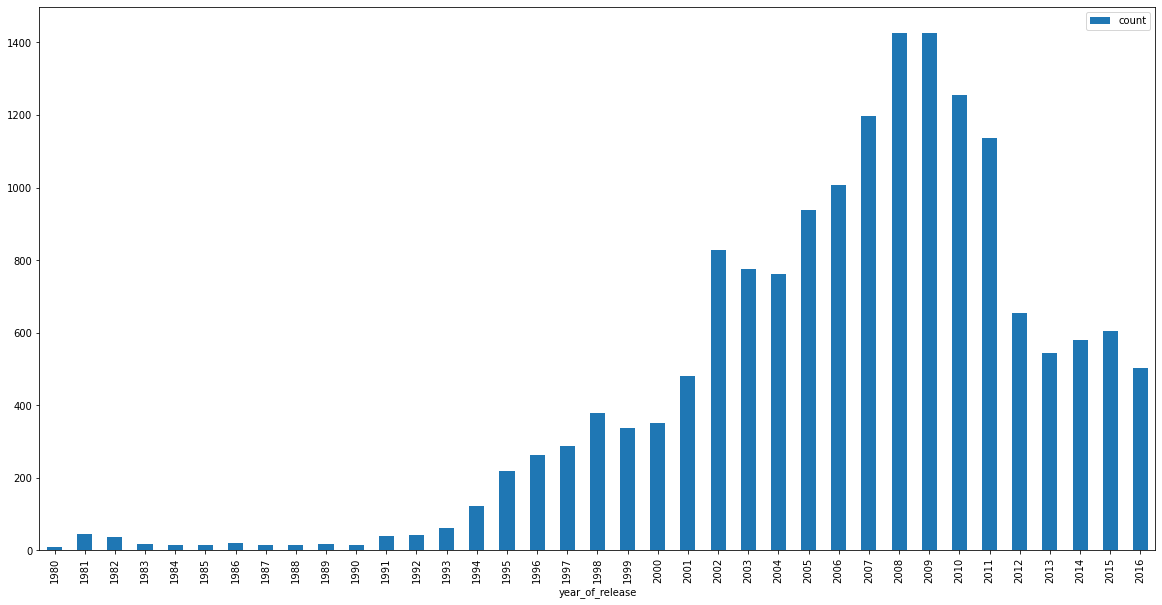

In [8]:
data.pivot_table(index='year_of_release', values='platform', aggfunc='count').plot(kind='bar', label='count',
                                                                                   figsize=(20, 10));
plt.legend(['count']);

The most games were released in 2008-2009.

platform
PS2     1062.33
X360     885.66
Wii      828.44
PS3      803.97
DS       746.86
PS       689.95
GBA      310.12
PS4      265.79
PSP      252.63
XB       249.02
Name: total_sales, dtype: float64

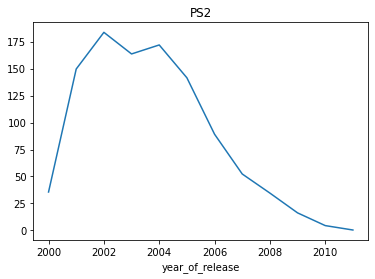

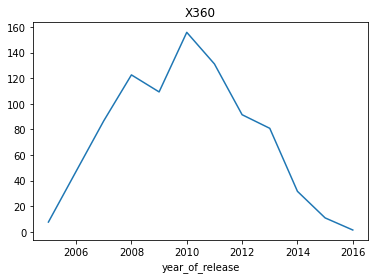

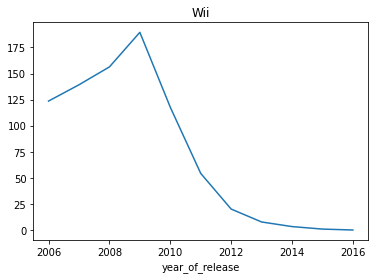

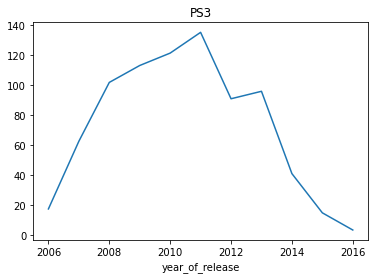

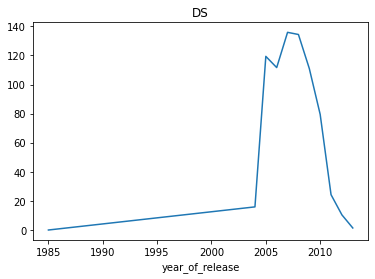

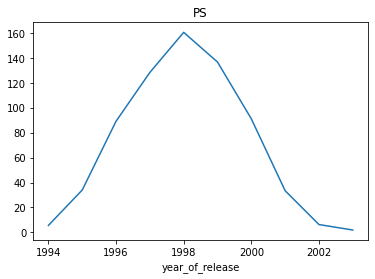

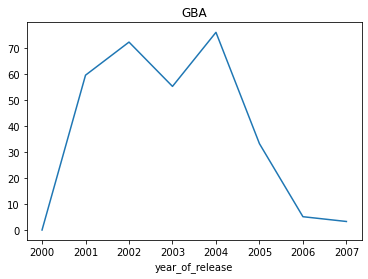

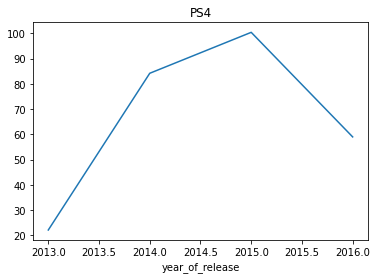

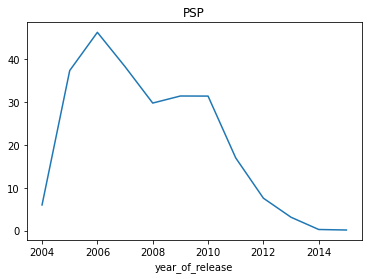

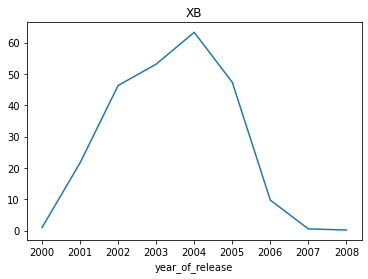

In [9]:
platform_top_sales = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)
display(platform_top_sales)
# platform_top_sales.plot();
# platform_top_sales.plot(kind='bar', figsize=(20, 10));

for platform in platform_top_sales.index:
    temp = data[data['platform'] == platform].groupby('year_of_release')['total_sales'].sum().plot(title=platform);
    plt.show()

Looking at this top 10 platforms, you can see that the average platform lifespan is about 10 years.

In [10]:
data = data.query('2013 <= year_of_release <= 2016', engine='python')
display(data)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,17.09
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,14.86
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,M,12.25
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,T,13.82
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,10.65
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,T,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01


Since the average lifespan of a platform is 10 years, this means that we are not interested in platforms whose ten years are already coming to an end, so we will take data from 2013 to 2016, where platforms were at their peak or where future favorites were born.

platform
PS4     265.79
PS3     154.66
XOne    145.05
3DS     136.97
X360    124.69
WiiU     59.94
PC       36.47
PSV      29.73
Wii      12.54
PSP       3.46
DS        1.42
Name: total_sales, dtype: float64

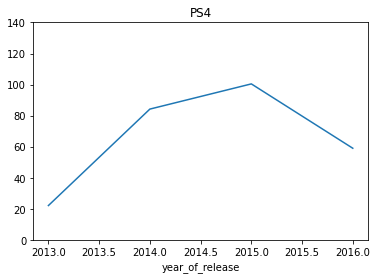

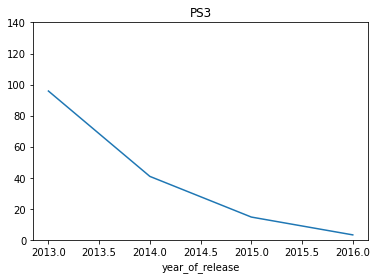

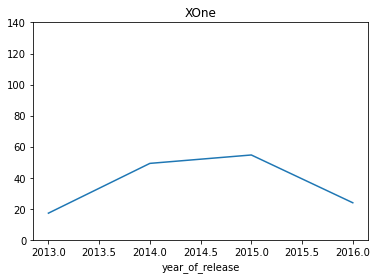

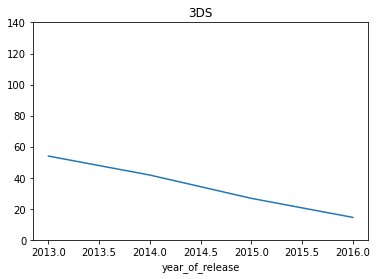

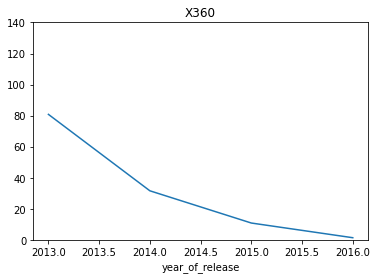

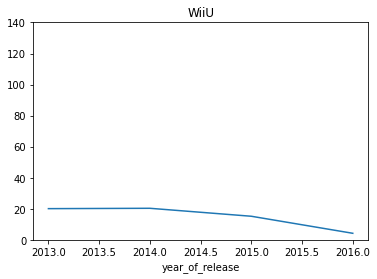

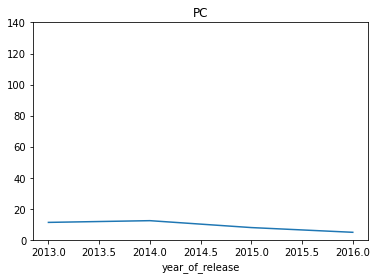

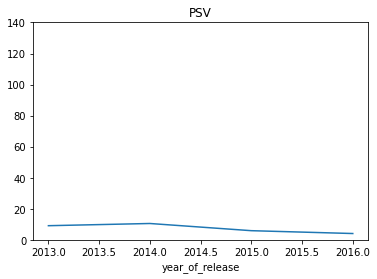

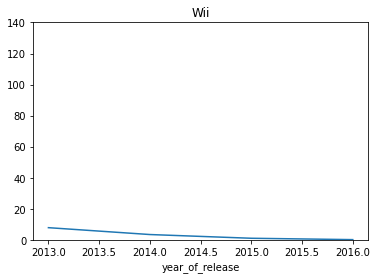

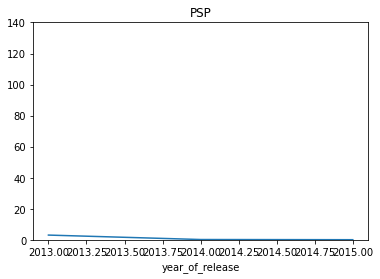

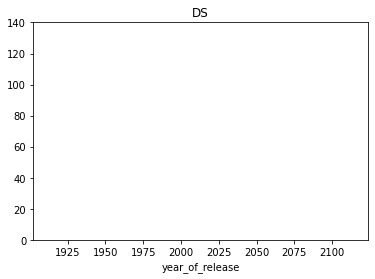

In [11]:
actual_period_df = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
display(actual_period_df)

for platform in actual_period_df.index:
    temp = data[data['platform'] == platform].groupby('year_of_release')['total_sales'].sum().plot(title=platform,
                                                                                                   ylim=(0, 140));
    plt.show()

The obvious best sellers from 2011 to 2016 are PS3, X360, PS4, 3DS, XOne. However, PS3 and X360 are dead platforms, since at the time of 2016 sales were about 0, but PS4 and XOne were at their peak in 2015. The 3DS is heading towards its end.

We will consider the new generation of consoles - PS4, XOne - to be potentially profitable.

PS4


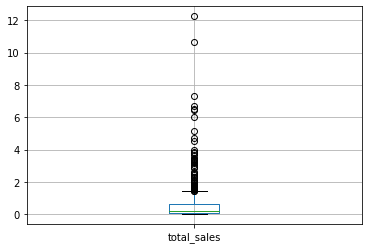

PS3


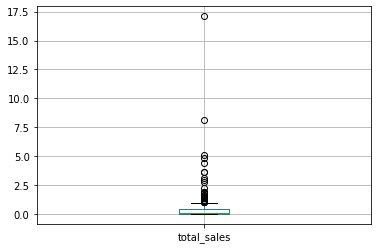

XOne


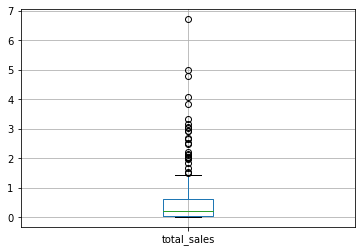

3DS


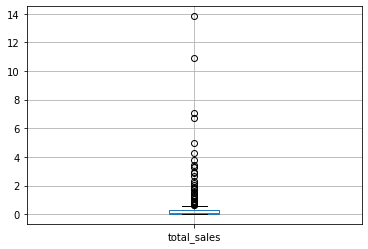

X360


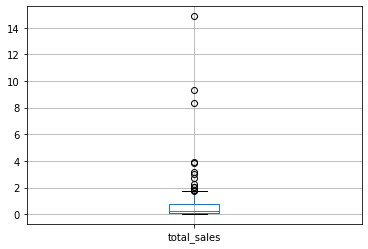

WiiU


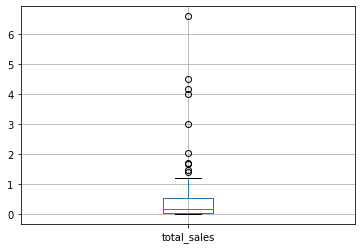

PC


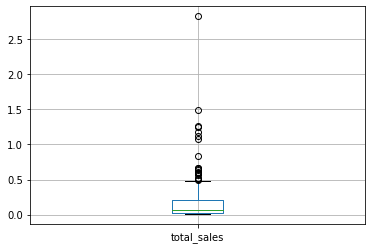

PSV


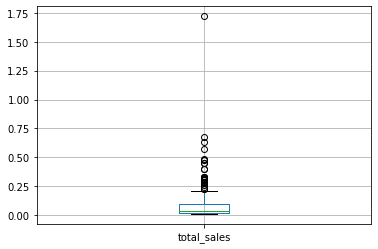

Wii


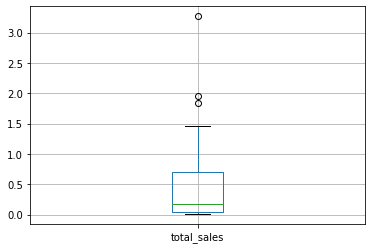

PSP


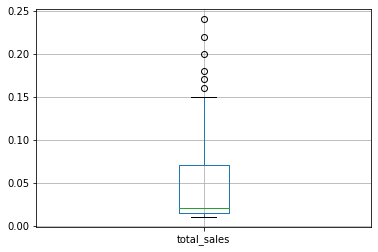

DS


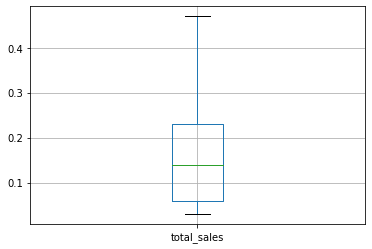

In [12]:
for platform in actual_period_df.index:
    print(platform)
    temp = data.query('platform == @platform').boxplot('total_sales');
    # data.query('platform == @platform')['total_sales'].hist(bins=100)
    plt.show()
# data.boxplot('total_sales');

If we consider the leading platforms, and indeed all platforms in general, we can see that most of the values ​​lie within 1 million copies, or even less, only a few developers manage to sell their game for more than 2 million copies, and even fewer - more than 5 million. The more sales, the fewer such games were ever released during the period 2011-2016.

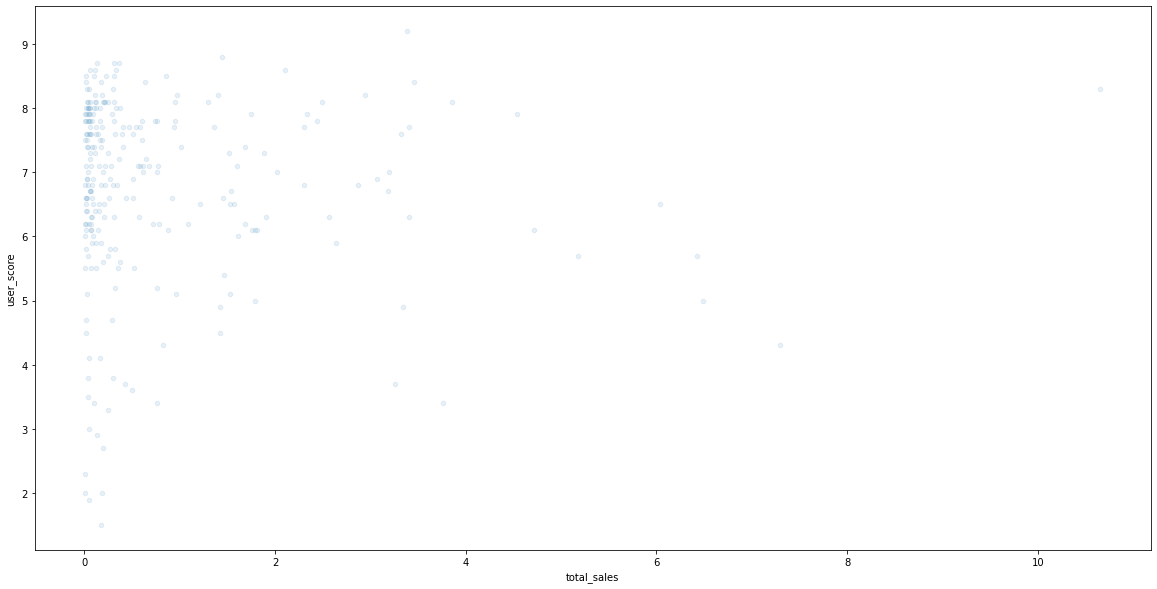

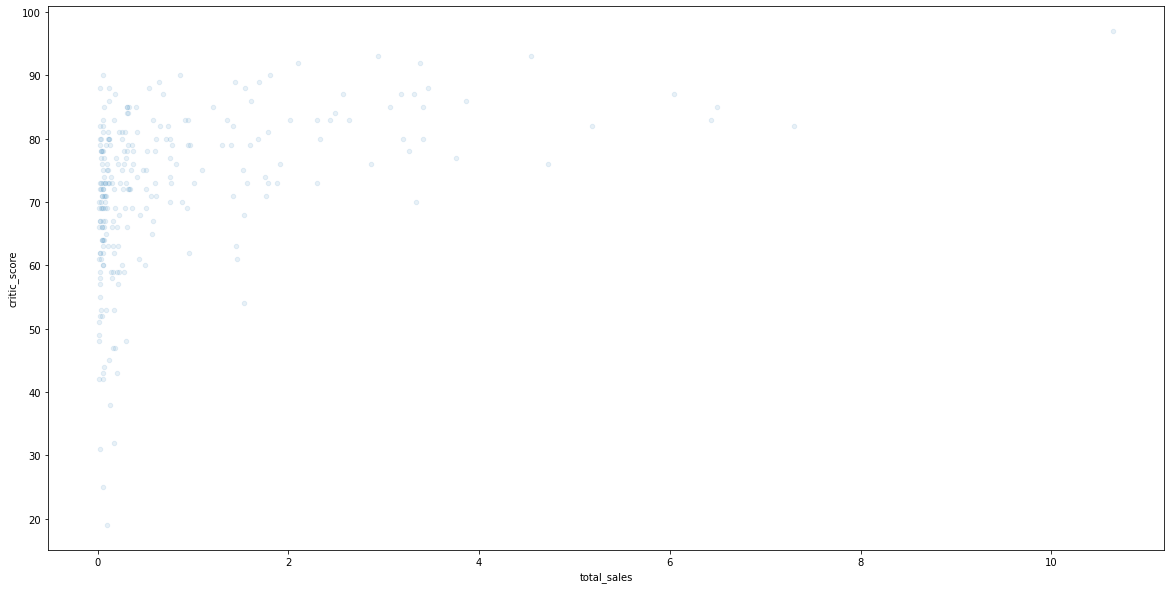

In [13]:
data.query('platform == "PS4"').plot(kind='scatter', x='total_sales', y='user_score', figsize=(20, 10), alpha=0.1);
# plt.xlim(0, 4);
plt.show()

data.query('platform == "PS4"').plot(kind='scatter', x='total_sales', y='critic_score', figsize=(20, 10), alpha=0.1);

# data[[data['platform'] == 'PS']['total_sales']].plot()


Based on these range diagrams, it cannot be said that user ratings have any impact on sales. It is impossible to find a clear relationship that the higher the reviews, the more sales. If you look at the range diagram with critics' ratings, then in general we can say that there is some clearer trend, much more high reviews for games with high sales compared to the previous range diagram, but still no clear relationship can be found.

In [14]:
print('Correlation between user score and total sales: \n',
      data.query('platform == "PS4"')['user_score'].corr(data['total_sales']))
print('Correlation between critic score and total sales: \n',
      data.query('platform == "PS4"')['critic_score'].corr(data['total_sales']))


Correlation between user score and total sales: 
 -0.03126053686666919
Correlation between critic score and total sales: 
 0.4058867746520127


Now let's compare our small findings on other platforms

In [15]:
for platform in actual_period_df.index:
    if platform != "PS4":
        print("Platform:", platform)
        data.query('platform == @platform').plot(kind='scatter', x='total_sales', y='user_score', figsize=(20, 10), alpha=0.1);
        plt.show()

        data.query('platform == @platform').plot(kind='scatter', x='total_sales', y='critic_score', figsize=(20, 10), alpha=0.1);
        plt.show()
        print(f'Correlation between user score and total sales on platform {platform}: \n',
        data.query('platform == @platform')['user_score'].corr(data['total_sales']))
        print(f'Correlation between critic score and total sales on platform {platform}: \n',
        data.query('platform == @platform')['critic_score'].corr(data['total_sales']))
        print()
        print()



As with the initial findings on the PS4 platform, no estimates affect the number of sales.

genre
Action          766
Role-Playing    292
Adventure       245
Sports          214
Shooter         187
Misc            155
Racing           85
Fighting         80
Platform         74
Simulation       62
Strategy         56
Puzzle           17
Name: genre, dtype: int64

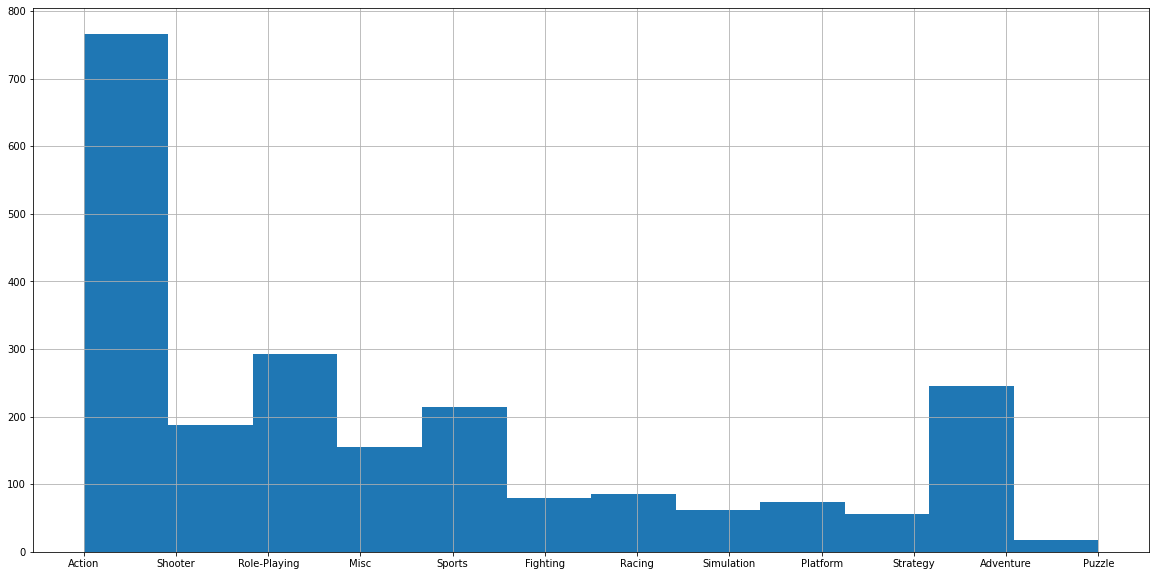

In [16]:
data['genre'].hist(figsize=(20, 10), bins=len(data['genre'].unique()));
count_of_genres = data.groupby('genre')['genre'].count().sort_values(ascending=False)
display(count_of_genres)

The most popular genre is Action. That says it all.

genre
Action          284.67
Shooter         204.21
Role-Playing    134.41
Sports          131.20
Misc             56.73
Platform         38.51
Racing           35.45
Fighting         31.75
Adventure        21.21
Simulation       20.30
Strategy          9.27
Puzzle            3.01
Name: total_sales, dtype: float64

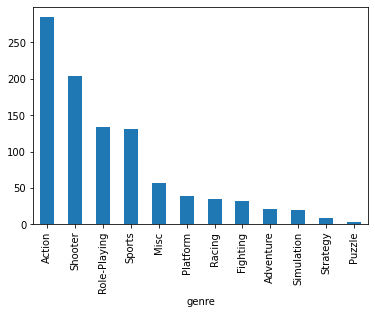

In [17]:
genre_top_sales = data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
display(genre_top_sales)
genre_top_sales.plot(kind='bar');

It is also the best-selling, and those genres that were popular - Shooters, Sports, Misc - are also in the top sales. But the adventure genre is almost at the bottom of the list, although it is a popular genre.

In [18]:
count_of_genres = data.groupby('genre')['genre'].count().sort_values(ascending=False)
display(count_of_genres)

genre
Action          766
Role-Playing    292
Adventure       245
Sports          214
Shooter         187
Misc            155
Racing           85
Fighting         80
Platform         74
Simulation       62
Strategy         56
Puzzle           17
Name: genre, dtype: int64

In [19]:
# my_iter = iter(count_of_genres.index)
# for i in range(len(count_of_genres.index)):
#     print(f'Ratio of the number of games in genre {next(my_iter)} to total sales {genre_top_sales[i]}', count_of_genres[i] / genre_top_sales[i])

<b>Step 4. Let’s create a portrait of a user in each region<b>

In [20]:
display(data)
data.info()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,17.09
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,14.86
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,M,12.25
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,T,13.82
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,10.65
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,T,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,E,0.01


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     991 non-null    float64
 9   user_score       1192 non-null   float64
 10  rating           2233 non-null   object 
 11  total_sales      2233 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 293.5+ KB


In [21]:
def portrait_of_the_user_of_region(region):
    print("Profile for region", region[0:2].upper())
    most_popular_platform = data.groupby('platform')[region].sum().sort_values(ascending=False)
    total_sales = most_popular_platform.sum()
    most_popular_platform = most_popular_platform.head()
    most_popular_platform_sales = most_popular_platform.sum()
    most_popular_platform['other'] = total_sales - most_popular_platform_sales
    # display(most_popular_platform)
    print("Sales share:")
    most_popular_platform.plot(kind='pie', autopct='%1.1f%%');
    plt.show()
    share_of_sales = most_popular_platform / total_sales
    print()
    print()
    print(f"Most popular genres in region {region[0:2].upper()}")
    data.groupby('genre')[region].sum().sort_values(ascending=False).plot(kind='pie', autopct='%1.1f%%');
    plt.show()
    print("Best-selling game ratings in region", region[0:2].upper())
    data.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).plot(kind='pie');
    plt.show()



Profile for region NA
Sales share:


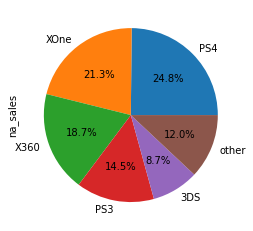



Most popular genres in region NA


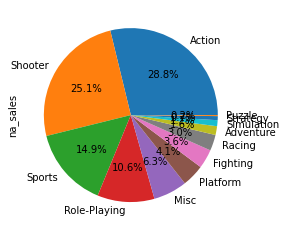

Best-selling game ratings in region NA


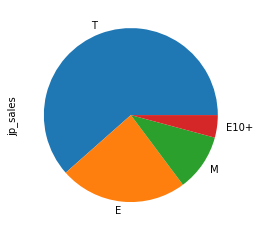

Profile for region EU
Sales share:


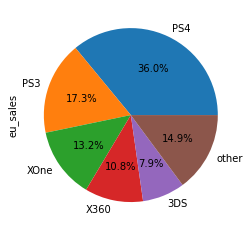



Most popular genres in region EU


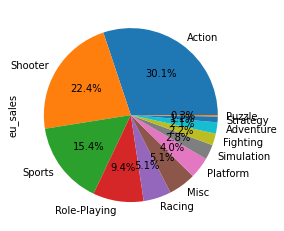

Best-selling game ratings in region EU


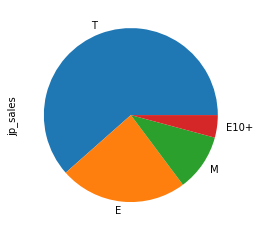

Profile for region JP
Sales share:


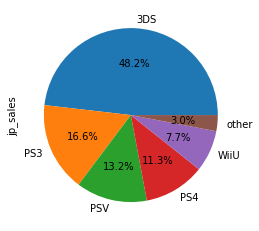



Most popular genres in region JP


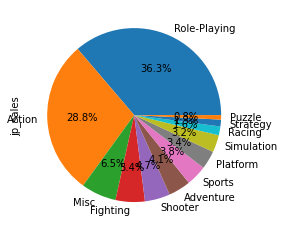

Best-selling game ratings in region JP


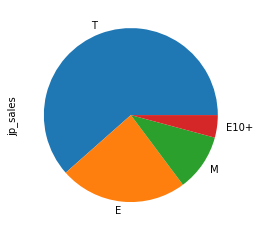

In [22]:
regions = ['na_sales', 'eu_sales', 'jp_sales']
regions = iter(regions)

portrait_of_the_user_of_region(next(regions))
portrait_of_the_user_of_region(next(regions))
portrait_of_the_user_of_region(next(regions))





<b>Now let's summarize the information about our portraits:<b>

The most popular platform among North American users is the X360, followed by the PS3, followed by the new platforms PS4 and XOne. The most popular genres among NA users are Action and Shooters. They outsell games rated T. As a result, teenagers in this region prefer fast-paced games.

The most popular platform among EU users is the PS3, followed immediately by its descendant, the PS4, and then the X360 and XOne series of consoles. In this region, the two most popular genres are Action and Shooters, and they are also preferred by teenagers (the best-selling game rating is T)

But with the JP region everything is a little different: the best-selling games were released on the portable console - 3DS, and only then comes the PS3. Players do not prefer shooters in this region, perhaps in the JP region everything is much stricter with this and it is difficult for shooters to get a T rating - which is also the most popular in JP. They prefer to play Role-playing games and Action.

<b>Step 5. Test the hypotheses<b>

Null hypothesis: The average user ratings of the XOne and PS4 platforms of the two populations are equal.
Alternative hypothesis: The average user ratings of the XOne and PS4 platforms of the two populations are NOT equal.

In [23]:
data_tmp = data[data['user_score'].notnull()]

alpha = .05  # critical level of statistical significance
# reject the null hypothesis if the p-value is below alpha

results = st.ttest_ind(
    data_tmp.loc[data_tmp['platform'] == 'XOne', 'user_score'],
    data_tmp.loc[data_tmp['platform'] == 'PC', 'user_score'],
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("Failed to reject the null hypothesis")

p-value: 0.14759594013430463
Failed to reject the null hypothesis


Null hypothesis: the average of user ratings for the Action and Sports genres of the two populations are equal.
Alternative hypothesis: The average of user ratings for the Action and Sports genres of the two populations are NOT equal.

In [24]:
results = st.ttest_ind(
    data_tmp.loc[data_tmp['genre'] == 'Action', 'user_score'],
    data_tmp.loc[data_tmp['genre'] == 'Sports', 'user_score'],
    equal_var=False
)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("Failed to reject the null hypothesis")

p-value: 1.4460039700704315e-20
Reject the null hypothesis


<b>Step 6. Write the general conclusion<b>

A large analysis of the dataframe was carried out. The column names were renamed, the data was converted to the required data types, and, if possible, the gaps were filled with median values ​​according to other criteria or with the most frequently encountered values. Possible reasons for the occurrence of gaps were described. Graphs, histograms, and range diagrams were built for various values, for example, look at the distribution of the number of game releases by year. Having analyzed sales by platform, 2011 - 2016 was selected for the current period, that is, 5 years. It was during this period that the platforms either died or were at their peak. A portrait of a user in each of the three regions was compiled, and hypotheses about the average of two general populations were also tested. Thus, after conducting a large analysis, we can say that the forecast for 2017 is that there will be a lot of games on PS4 and XOne in the action and shooter genre, they will be the most profitable and leading with a T rating.